Copyright (c) 2026 ETH Zurich  
Authors: see CONTRIBUTORS.md  
Licensed under the MIT License. See the LICENSE file in the repository root.  

In [1]:

# Cap BLAS/OpenMP thread fanout before importing numpy/torch.
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '32')
os.environ.setdefault('OMP_NUM_THREADS', os.environ['OPENBLAS_NUM_THREADS'])
os.environ.setdefault('MKL_NUM_THREADS', os.environ['OPENBLAS_NUM_THREADS'])

import sys
# import json
# import dataclasses
from pathlib import Path
from datetime import datetime, timedelta
from dotenv import load_dotenv

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
from safetensors.torch import load_file as st_load_file

# Runtime selection: default to GPU when available, otherwise CPU.
# Set FORCE_CPU = True and rerun this cell to force CPU execution.
FORCE_CPU = False
HAS_CUDA = torch.cuda.is_available()
USE_CUDA = HAS_CUDA and not FORCE_CPU
DEVICE = torch.device('cuda' if USE_CUDA else 'cpu')
MODEL_AUTOCAST = USE_CUDA
ENCODER_ACTIVATION_CHECKPOINTING = USE_CUDA

torch.set_num_threads(min(16, os.cpu_count() or 1))

# Resolve repository root so local imports work whether the notebook is run
# from notebooks/ or the project root.
CWD = Path.cwd().resolve()
if (CWD / 'esfm').exists():
    REPO_ROOT = CWD
elif (CWD.parent / 'esfm').exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from config import parse_args

load_dotenv() # Load environment variables

# NOTE: esfm is intentionally NOT imported here.
# posencoding.py and fourier.py read grid_deg_delta from sys.argv at import
# time via parse_known_args(). You must set sys.argv with the correct value
# for the chosen config BEFORE importing esfm. That happens in the
# "Import ESFM with correct grid_deg_delta" cell below.

print('CUDA available:', HAS_CUDA)
print('FORCE_CPU     :', FORCE_CPU)
print('Runtime device:', DEVICE)
print('Model autocast:', MODEL_AUTOCAST)
print('Encoder activation checkpointing:', ENCODER_ACTIVATION_CHECKPOINTING)
print('Repository root:', REPO_ROOT)
print('torch threads:', torch.get_num_threads())

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


CUDA available: True
FORCE_CPU     : False
Runtime device: cuda
Model autocast: True
Encoder activation checkpointing: True
Repository root: /users/tligawa/ESFM
torch threads: 16



## Select a model

Set `EXPERIMENT_NAME` to one of the available ERA5-based ESFM checkpoints below and run the cell.

**ERA5 models** (work with the automatic Weatherbench2 data download in Step 2):
- `ESFM_s_nm` – Second stage training of ESFM_s **without** masking protocol
- `ESFM_s_nm_pre` – First stage training of `ESFM_s_nm` **without** masking protocol
- `ESFM_s_enc_KD_nm` – Encoder knowledge-distillation pre-pretraining
- `ESFM_s_nm_ens` – Ensemble model (8 members)  
- `ESFM_s_wm` – Second stage training of ESFM_s **with** masking protocol
- `ESFM_s_wm_pre` – First stage training of `ESFM_s_wm` **with** masking protocol
- `ESFM_s_wm_ri` – Second stage training of `ESM_s_wm_ri` **with** masking protocol 
- `ESFM_s_wm_ri_pre` – First stage of `ESM_s_wm_ri` **with** masking protocol from random initialization
- `ESFM_s_wm_ci` – Third stage training of `ESFM_s_wm_ci` **with** masking protocol
- `ESFM_s_wm_ci_pre` – Second stage training of `ESFM_s_wm_ci` **with** masking protocol
- `ESFM_s_wm_ci_prepre` – First stage pretraining of `ESFM_s_wm_ci` **with** masking protocol on 8xCMIP6 datasets

**Station / MODIS models** (require preprocessed data, sample data will be made available soon):
- `ESFM_s_wm_modis` – Second stage of `ESFM_s_wm` finetuned on MODIS satellite data
- `ESFM_s_wm_modis_pre` – First stage of `ESFM_s_wm` finetuned on MODIS satellite data
- `ESFM_s_nm_e11k_lt6h` – `ESFM_s_wm` finetuned on ECMWF 11k data **without** masking protocol and 6h lead  
- `ESFM_s_nm_e11k_lt12h` – `ESFM_s_wm` finetuned on ECMWF 11k data **without** masking protocol and 12h lead  
- `ESFM_s_nm_e11k_lt24h` – `ESFM_s_wm` finetuned on ECMWF 11k data **without** masking protocol and 24h lead  
- `ESFM_s_wm_w5k_lt6h` - `ESFM_s_wm` finetuned on Weather-5K data **with** masking protocol and 6h lead  
- `ESFM_s_wm_w5k_lt12h` - `ESFM_s_wm` finetuned on Weather-5K data **with** masking protocol and 12h lead  
- `ESFM_s_wm_w5k_lt24h` - `ESFM_s_wm` finetuned on Weather-5K data **with** masking protocol and 24h lead  

Checkpoints are downloaded automatically from Hugging Face (`ESFM/<model_name>`).  
Set `USE_LOCAL_CHECKPOINT = True` and `LOCAL_CKPT_PATH` to use a local file instead.

In [9]:

# ── User configuration ────────────────────────────────────────────────────────
EXPERIMENT_NAME   = 'ESFM_s_nm'        # pick a model name from the list above
INIT_TIME         = '2023-01-03T00:00:00'  # forecast init time (must be in the WB2 zarr)
USE_SAFETENSORS   = True               # prefer .safetensors over .ckpt when available

# Local checkpoint override (leave both as None to download from Hugging Face).
USE_LOCAL_CHECKPOINT = False
LOCAL_CKPT_PATH      = None  # e.g. '/path/to/ESFM_s_nm.safetensors'

HF_ORG = 'ESFM'  # Hugging Face organisation hosting the model weights
# ─────────────────────────────────────────────────────────────────────────────

# Infer whether this experiment uses ERA5 / WB2 data or requires possibly local
# station / MODIS data that is not available via the public zarr.
def _is_era5_model(name: str) -> bool:
    n = name.lower()
    return not any(tag in n for tag in ('e11k', 'w5k', 'modis'))

def is_experiment_in_list_of_models(experiment_name: str) -> bool:
    """Check if the given experiment name is in the list of available models."""
    available_models = [
        p.stem.removeprefix('config_')
        for p in (REPO_ROOT / 'configs').glob('config_*.yaml')
    ]
    return experiment_name in available_models

if not is_experiment_in_list_of_models(EXPERIMENT_NAME):
    raise ValueError(f'Experiment name not found: {EXPERIMENT_NAME}')

IS_ERA5_MODEL = _is_era5_model(EXPERIMENT_NAME)
print(f'Selected model : {EXPERIMENT_NAME}')
print(f'ERA5-compatible: {IS_ERA5_MODEL}')
if not IS_ERA5_MODEL:
    print('WARNING: this model requires local station/MODIS data.\nUnexpected results may occur when using only ERA5 data in this notebook.\n')

# Locate the experiment config.
CONFIG_PATH = REPO_ROOT / 'configs' / f'config_{EXPERIMENT_NAME}.yaml'
assert CONFIG_PATH.exists(), f'Config not found: {CONFIG_PATH}'

# Resolve the checkpoint to use.
def _resolve_checkpoint(experiment_name: str) -> Path:
    """Return a local path to the checkpoint, downloading from HF if needed."""
    if USE_LOCAL_CHECKPOINT and LOCAL_CKPT_PATH is not None:
        p = Path(LOCAL_CKPT_PATH)
        assert p.exists(), f'Local checkpoint not found: {p}'
        return p

    ext = '.safetensors' if USE_SAFETENSORS else '.ckpt'
    filename = f'{experiment_name}{ext}'
    repo_id  = f'{HF_ORG}/{experiment_name}'

    try:
        from huggingface_hub import hf_hub_download
        print(f'Downloading {filename} from {repo_id} …')
        local_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type='model')
        return Path(local_path)
    except Exception as e:
        raise RuntimeError(
            f'Could not download {filename} from {repo_id}.\n'
            f'Reason: {e}\n'
            f'Set USE_LOCAL_CHECKPOINT=True and provide LOCAL_CKPT_PATH to use a local file.'
        ) from e

CKPT_PATH = _resolve_checkpoint(EXPERIMENT_NAME)
print(f'Checkpoint     : {CKPT_PATH}')

# Parse the experiment config (re-uses the same parser as training/inference scripts).
dataset_yaml_path = str(REPO_ROOT / "dataset_config.yaml")
# This must happen BEFORE importing esfm so that args.grid_deg_delta is known.
args = parse_args(['--config', str(CONFIG_PATH),
                  '--dataset_config_path', dataset_yaml_path])
print(f'grid_deg_delta : {args.grid_deg_delta}')

Selected model : ESFM_s_nm
ERA5-compatible: True
Checkpoint     : /ritom/scratch/cscs/tligawa/jupyter_data/cache/huggingface/hub/models--ESFM--ESFM_s_nm/snapshots/f4570364ff8b1cc2b80baaac7354146cad740200/ESFM_s_nm.safetensors
Loading config from /users/tligawa/ESFM/configs/config_ESFM_s_nm.yaml. Will overwrite any command line arguments with yaml content.
grid_deg_delta : 0.01


## Import ESFM with Correct `grid_deg_delta` parameter

`posencoding.py` and `fourier.py` inside the `esfm` package read `grid_deg_delta` via
`parse_known_args()` **at module import time**.  Any config that sets a non-default
`grid_deg_delta` (e.g. `config_ESFM_s_wm` uses `0.00001`) will silently corrupt the
positional/scale encoding if `esfm` is imported before the config is loaded.

The cell below injects the correct value into `sys.argv` **before** the first `import esfm`,
so the module-level initialisation sees the right number.


In [10]:

# ── Unload any previously cached esfm modules ────────────────────────────────
# Purging sys.modules forces every esfm submodule to re-execute its top-level
# code (including parse_known_args()) on the next import, so changing
# EXPERIMENT_NAME and re-running this cell always picks up the correct
# grid_deg_delta without needing a kernel restart.
_esfm_keys = [k for k in sys.modules if k == 'esfm' or k.startswith('esfm.')]
for _k in _esfm_keys:
    del sys.modules[_k]
if _esfm_keys:
    print(f"Unloaded {len(_esfm_keys)} cached esfm module(s): {_esfm_keys}")

# ── Set sys.argv so esfm's module-level parse_known_args() gets the right value ─
# posencoding.py and fourier.py call parse_known_args() at import time.
# We must inject grid_deg_delta BEFORE importing esfm (matters for fresh kernels).
_grid_deg_delta = args.grid_deg_delta

_argv_stripped = [a for a in sys.argv if not a.startswith('--grid_deg_delta')]
sys.argv = _argv_stripped + [f'--grid_deg_delta={_grid_deg_delta}']
print(f"sys.argv grid_deg_delta set to: {_grid_deg_delta}")

# ── Now safe to import esfm ───────────────────────────────────────────────────
from esfm import ESFM, Batch, Metadata
from esfm.normalisation import load_normalization_stats
import esfm.model.fourier as _fou
import esfm.model.posencoding as _pe
from esfm.area import area as _area

# ── Directly patch the module-level FourierExpansion objects ─────────────────
# encoder.py does `from esfm.model.fourier import pos_expansion, scale_expansion`,
# which means encoder.pos_expansion IS the same Python object as fourier.pos_expansion.
# Mutating .lower propagates to ALL modules that imported these singletons,
# even if esfm was already cached in sys.modules from a previous cell execution.
_min_patch_area = _area(
    torch.tensor(
        [[90, 0], [90, _grid_deg_delta],
         [90 - _grid_deg_delta, _grid_deg_delta], [90 - _grid_deg_delta, 0]],
        dtype=torch.float64,
    )
).item()

_fou.pos_expansion.lower   = _grid_deg_delta   # lat/lon encoding lower wavelength
_fou.scale_expansion.lower = _min_patch_area   # patch-area encoding lower wavelength
_pe.grid_deg_delta         = _grid_deg_delta   # used at runtime in pos_scale_enc_grid

print(f"pos_expansion.lower    = {_fou.pos_expansion.lower}")
print(f"scale_expansion.lower  = {_fou.scale_expansion.lower:.6e}")
print(f"posencoding.grid_deg_delta = {_pe.grid_deg_delta}")

Unloaded 18 cached esfm module(s): ['esfm.normalisation', 'esfm.batch', 'esfm.model', 'esfm.area', 'esfm.model.fourier', 'esfm.model.perceiver', 'esfm.model.util', 'esfm.model.film', 'esfm.model.decoder_esfm', 'esfm.model.patchembed', 'esfm.model.posencoding', 'esfm.model.encoder', 'esfm.model.lora', 'esfm.model.swin3d', 'esfm.model.esfm', 'esfm.model.esfm_encoder_only', 'esfm.rollout', 'esfm']
sys.argv grid_deg_delta set to: 0.01
pos_expansion.lower    = 0.01
scale_expansion.lower  = 1.081409e-04
posencoding.grid_deg_delta = 0.01


### Notes so far
Ensure that the first author configs for instance in the file `home/ESFM/configs/config_ESFM_s_nm_e11k_lt6h.yaml` is changed to the current user's name e.g `/ritom/scratch/cscs/tligawa/ai-4-weather/experiments/ESFMs/ESFM_outputs/ESFM_s_wm_e11k_lt6h` or `/users/tligawa/ESFM/dataset_config.yaml` to help with the `dataset_config.yaml`config_ESFM_s_nm_e11k_lt6h as opposed to the first author of the paper e.g `/iopsstor/scratch/cscs/fozdemir/ESFM_outputs/ESFM_s_nm`

In [11]:

# ── Build model architecture ──────────────────────────────────────────────────
def _build_model(args, surf_vars, atmos_vars, static_vars):
    """Instantiate an ESFM model from parsed config args."""
    if args.str_architecture_size == 'small':
        enc_depths, enc_heads = (2, 6, 2), (4, 8, 16)
        dec_depths, dec_heads = (2, 6, 2), (16, 8, 4)
        embed_dim, num_heads  = 256, 8
    elif args.str_architecture_size == 'large':
        enc_depths, enc_heads = (6, 10, 8), (8, 16, 32)
        dec_depths, dec_heads = (8, 10, 6), (32, 16, 8)
        embed_dim, num_heads  = 512, 16
    else:
        raise ValueError(f'Unknown architecture size: {args.str_architecture_size}')

    return ESFM(
        use_lora=False,
        autocast=MODEL_AUTOCAST,
        surf_vars=surf_vars,
        static_vars=static_vars,
        atmos_vars=atmos_vars,
        encoder_depths=enc_depths,
        encoder_num_heads=enc_heads,
        decoder_depths=dec_depths,
        decoder_num_heads=dec_heads,
        embed_dim=embed_dim,
        num_heads=num_heads,
        drop_path=0.2,
        num_ensemble=args.num_ensemble,
        variable_aggregation=args.variable_aggregation,
        use_resolution_specific_patch_tokenizers=args.use_resolution_specific_patch_tokenizers,
        disable_flashattention=args.disable_flashattention,
        stabilise_level_agg=args.stabilise_level_agg,
        add_qk_norm_to_swin3d=args.add_qk_norm_to_swin3d,
        encoder_activation_checkpointing=ENCODER_ACTIVATION_CHECKPOINTING,
        absolute_time_embedding_in_minutes=args.absolute_time_embedding_in_minutes,
        add_token_pos_embedding_in_decoder=args.add_token_pos_embedding_in_decoder,
        num_max_ensembles=args.num_max_ensembles,
        ensemble_adaln_scale_bias=args.ensemble_adaln_scale_bias,
    )


def _gather_model_vars(dataset_config_path, data_sources):
    """Read the dataset config and collect the union of variable names for the model."""
    import yaml
    from utils.dataset import d_srf_abr2full, d_atmos_abr2full, d_static_abr2full
    with open(dataset_config_path) as f:
        yml = yaml.safe_load(f)
    surf, atmos, static = set(), set(), set()
    for src in data_sources:
        conf = yml[src]['conf']
        mapping = conf.get('variable_name_mapping', {})
        surf   |= {mapping.get(v, v) for v in conf['surf_vars']}
        atmos  |= {mapping.get(v, v) for v in conf['atmos_vars']}
        static |= {mapping.get(v, v) for v in conf['static_vars']}
    return tuple(sorted(surf)), tuple(sorted(atmos)), tuple(sorted(static))


SURF_VARS, ATMOS_VARS, STATIC_VARS = _gather_model_vars(args.dataset_config_path, args.data_sources)
print(f'\nModel surf  vars : {SURF_VARS}')
print(f'Model atmos vars : {ATMOS_VARS}')
print(f'Model static vars: {STATIC_VARS}')

device = DEVICE
print(f'\nDevice: {device}')

model = _build_model(args, SURF_VARS, ATMOS_VARS, STATIC_VARS).to(device)

# ── Load checkpoint weights ───────────────────────────────────────────────────
def _load_state_dict(ckpt_path: Path) -> dict:
    if ckpt_path.suffix == '.safetensors':
        state = st_load_file(str(ckpt_path), device='cpu')
    else:
        obj = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
    # Strip optional 'net.' prefix added by Lightning wrappers.
    return {(k[4:] if k.startswith('net.') else k): v for k, v in state.items()}

state_dict = _load_state_dict(CKPT_PATH)
try:
    model.load_state_dict(state_dict, strict=True)
    print('Loaded checkpoint with strict=True')
except RuntimeError as e:
    print(f'strict=True failed ({e}), retrying with strict=False …')
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f'  missing keys: {len(missing)}, unexpected keys: {len(unexpected)}')

model.eval()
print('Model ready.')


Model surf  vars : ('10u', '10v', '2t', 'msl')
Model atmos vars : ('q', 't', 'u', 'v', 'z')
Model static vars: ('lsm', 'slt', 'z')

Device: cuda
Loaded checkpoint with strict=True
Model ready.



## Load sample data

For ERA5-based models the cell below fetches a single 6-hour forecast sample directly from the public Weatherbench2 ERA5 zarr on Google Cloud Storage.  For station / MODIS models this cell is skipped and you should load your own data instead.

The zarr is opened lazily (no full download) and only the three required timesteps are materialised: `INIT_TIME − 6 h`, `INIT_TIME`, and `INIT_TIME + 6 h` (the forecast target used for visualisation).


In [12]:

# WB2 public ERA5 zarr — needs gcsfs.
# !pip install gcsfs
WB2_ZARR_URL = (
    'gs://weatherbench2/datasets/era5/'
    '1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
)

# Pressure levels to load.
ATMOS_LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]

# ERA5 variable name mapping (WB2 full names → ESFM abbreviations).
_SURF_FULL2ABR  = {
    '2m_temperature':              '2t',
    '10m_u_component_of_wind':     '10u',
    '10m_v_component_of_wind':     '10v',
    'mean_sea_level_pressure':     'msl',
}
_ATMOS_FULL2ABR = {
    'geopotential':            'z',
    'u_component_of_wind':     'u',
    'v_component_of_wind':     'v',
    'temperature':             't',
    'specific_humidity':       'q',
}
_STATIC_FULL2ABR = {
    'land_sea_mask':              'lsm',
    'geopotential_at_surface':    'z',
    'soil_type':                  'slt',
}

print(f'Opening WB2 zarr (lazy) …')
ds = xr.open_zarr(WB2_ZARR_URL,
                  storage_options={'token': 'anon'}, # Bypass authentification
                  chunks=None)

# The zarr has 721 latitudes; ESFM uses 720 (drop the south pole duplicate).
lat_vals = ds.latitude.values
if len(lat_vals) == 721:
    lat_vals = lat_vals[:-1]   # keep 90 N … −89.75 N (720 points)
lon_vals = ds.longitude.values  # 0 … 359.75 (1440 points)

# Three timesteps needed: t-6h (x0), t (x1), t+6h (y).
t1 = np.datetime64(INIT_TIME)
t0 = t1 - np.timedelta64(6, 'h')
ty = t1 + np.timedelta64(6, 'h')
times_input  = [t0, t1]   # two model input steps
times_all    = [t0, t1, ty]

# Convert numpy.datetime64 → Python datetime for Metadata (encoder calls .timestamp()).
def _np64_to_dt(t: np.datetime64) -> datetime:
    ts = float((t - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(ts)

t0_dt = _np64_to_dt(t0)
t1_dt = _np64_to_dt(t1)
ty_dt = _np64_to_dt(ty)

print(f'  x0 = {t0}  x1 = {t1}  y = {ty}')
print(f'  Selecting {len(ATMOS_LEVELS)} pressure levels × 3 timesteps …')

ds_sub = (
    ds
    .sel(latitude=lat_vals, longitude=lon_vals, method='nearest')
    .sel(level=ATMOS_LEVELS)
    .sel(time=times_all)
)

# ── Surface variables ─────────────────────────────────────────────────────
def _load_surf(full_name: str) -> np.ndarray:
    """Load (3, H, W) array; return NaNs if the variable is not in the zarr."""
    if full_name in ds_sub.data_vars:
        arr = ds_sub[full_name].values.astype(np.float32)   # (3, H, W)
    elif full_name in ds.data_vars:
        arr = ds.sel(latitude=lat_vals, longitude=lon_vals, method='nearest') \
                .sel(time=times_all)[full_name].values.astype(np.float32)
    else:
        print(f'  Surface variable "{full_name}" not found in zarr — using NaNs.')
        arr = np.nan * np.ones((3, len(lat_vals), len(lon_vals)), dtype=np.float32)
    return arr

surf_abrs_needed = [abr for abr in SURF_VARS if abr in _SURF_FULL2ABR.values()]
abr2full_surf = {v: k for k, v in _SURF_FULL2ABR.items()}

raw_surf = {}
for abr in surf_abrs_needed:
    full = abr2full_surf.get(abr)
    if full is not None:
        raw_surf[abr] = _load_surf(full)

# Ensure every requested surface variable exists in raw_surf.
for abr in SURF_VARS:
    if abr not in raw_surf:
        raw_surf[abr] = np.full((3, len(lat_vals), len(lon_vals)), np.nan, dtype=np.float32)
        print(f'  Surface variable "{abr}" not provided by loaded data source — filling with NaNs.')

# ── Atmospheric variables ─────────────────────────────────────────────────
abr2full_atmos = {v: k for k, v in _ATMOS_FULL2ABR.items()}

raw_atmos = {}
for abr in ATMOS_VARS:
    full = abr2full_atmos.get(abr)
    if full and full in ds_sub.data_vars:
        raw_atmos[abr] = ds_sub[full].values.astype(np.float32)  # (3, L, H, W)
    elif full and full in ds.data_vars:
        raw_atmos[abr] = ds.sel(latitude=lat_vals, longitude=lon_vals, method='nearest') \
                            .sel(level=ATMOS_LEVELS).sel(time=times_all)[full].values.astype(np.float32)
    else:
        print(f'  Atmospheric variable "{abr}" ({full}) not found in zarr — using NaNs.')
        raw_atmos[abr] = np.nan * np.ones((3, len(ATMOS_LEVELS), len(lat_vals), len(lon_vals)), dtype=np.float32)

# ── Static variables ──────────────────────────────────────────────────────
abr2full_static = {v: k for k, v in _STATIC_FULL2ABR.items()}

raw_static = {}
for abr in STATIC_VARS:
    full = abr2full_static.get(abr)
    if full and full in ds_sub.data_vars:
        raw_static[abr] = ds_sub[full].values.astype(np.float32)  # (H, W)
    elif full and full in ds.data_vars:
        raw_static[abr] = ds.sel(latitude=lat_vals, longitude=lon_vals, method='nearest')[full].values.astype(np.float32)
    else:
        # Variable absent in zarr (e.g. soil_type): fill with zeros.
        print(f'  Static variable "{abr}" ({full}) not found in zarr — using NaNs.')
        raw_static[abr] = np.nan * np.ones((len(lat_vals), len(lon_vals)), dtype=np.float32)

print('  Done materialising data.')

# ── Load normalisation statistics ─────────────────────────────────────────
STATS_PATH = REPO_ROOT / 'esfm' / 'normalization_stats_inference_notebook.json' # contains a merge of several datasets.
locations, scales = load_normalization_stats(str(STATS_PATH))
print(f'Loaded base normalisation stats: {STATS_PATH}')

locations_t = {k: torch.tensor(v, dtype=torch.float32) for k, v in locations.items()}
scales_t    = {k: torch.tensor(v, dtype=torch.float32) for k, v in scales.items()}
lead_time_seconds_t = torch.tensor(timedelta(hours=6).total_seconds(), dtype=torch.float32)

# ── Build Batch objects ───────────────────────────────────────────────────
lat_t = torch.from_numpy(lat_vals.astype(np.float32))
lon_t = torch.from_numpy(lon_vals.astype(np.float32))

def _to_surf_tensor(arr_3hw: np.ndarray, t_slice) -> torch.Tensor:
    """Shape (3, H, W) → (1, T, H, W) for T timesteps."""
    return torch.from_numpy(arr_3hw[t_slice][None])   # (1, T, H, W)

def _to_atmos_tensor(arr_3lhw: np.ndarray, t_slice) -> torch.Tensor:
    """Shape (3, L, H, W) → (1, T, L, H, W)."""
    return torch.from_numpy(arr_3lhw[t_slice][None])  # (1, T, L, H, W)

def _to_static_tensor(arr_hw: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(arr_hw)  # (H, W)

# Common metadata fields.
_meta_kwargs = dict(
    dataset_name='era5',
    lat=lat_t,
    lon=lon_t,
    atmos_levels=tuple(int(l) for l in ATMOS_LEVELS),
    locations=locations_t,
    scales=scales_t,
    grid_resolution=0.25,
    is_global_observation=True,
    atmos_vars_output=None,
    surf_vars_output=None,
    atmos_levels_output=tuple(int(l) for l in ATMOS_LEVELS),
    lead_time_seconds=lead_time_seconds_t,
)

# Input batch: uses timesteps 0 and 1 (t0, t1).
# IMPORTANT: metadata.time must contain exactly B=1 timestamp (the most recent input step t1).
# The encoder builds one absolute-time embedding per entry in metadata.time and treats
# the length as the batch size. Passing (t0_dt, t1_dt) would silently broadcast B from 1→2.
batch_x = Batch(
    surf_vars  ={abr: _to_surf_tensor(arr, slice(0, 2))   for abr, arr in raw_surf.items()},
    atmos_vars ={abr: _to_atmos_tensor(arr, slice(0, 2))  for abr, arr in raw_atmos.items()},
    static_vars={abr: _to_static_tensor(arr)               for abr, arr in raw_static.items()},
    metadata=Metadata(
        time=(t1_dt,),   # only the most recent input timestep (matches production dataset)
        **_meta_kwargs,
    ),
)

# Target batch: uses timestep 2 (ty) — for optional ground-truth comparison.
batch_y = Batch(
    surf_vars  ={abr: _to_surf_tensor(arr, slice(2, 3))   for abr, arr in raw_surf.items()},
    atmos_vars ={abr: _to_atmos_tensor(arr, slice(2, 3))  for abr, arr in raw_atmos.items()},
    static_vars={abr: _to_static_tensor(arr)               for abr, arr in raw_static.items()},
    metadata=Metadata(
        time=(ty_dt,),
        **_meta_kwargs,
    ),
)

print(f'\nbatch_x surf vars  : {list(batch_x.surf_vars.keys())}')
print(f'batch_x atmos vars : {list(batch_x.atmos_vars.keys())}')
print(f'batch_x static vars: {list(batch_x.static_vars.keys())}')
print(f'Spatial shape      : {batch_x.spatial_shape}')
print(f'x_time             : {batch_x.metadata.time}')
print(f'y_time             : {batch_y.metadata.time}')

Opening WB2 zarr (lazy) …


/tmp/ipykernel_154746/633120160.py:52: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts)


  x0 = 2023-01-02T18:00:00  x1 = 2023-01-03T00:00:00  y = 2023-01-03T06:00:00
  Selecting 13 pressure levels × 3 timesteps …
  Done materialising data.
Loaded base normalisation stats: /users/tligawa/ESFM/esfm/normalization_stats_inference_notebook.json

batch_x surf vars  : ['10u', '10v', '2t', 'msl']
batch_x atmos vars : ['q', 't', 'u', 'v', 'z']
batch_x static vars: ['lsm', 'slt', 'z']
Spatial shape      : torch.Size([720, 1440])
x_time             : (datetime.datetime(2023, 1, 3, 0, 0),)
y_time             : (datetime.datetime(2023, 1, 3, 6, 0),)



## Run inference

The model normalises inputs internally, runs the forward pass, and returns un-normalised predictions in physical units.  The first returned object (`pred`) holds the ensemble mean; `std` holds the ensemble standard deviation (zero for single-member models).


In [13]:

assert batch_x is not None, 'batch_x is None — run previous cell first.'

# Drop any variables loaded from the zarr that the model was not trained on.
for key in list(batch_x.surf_vars.keys()):
    if key not in SURF_VARS:
        del batch_x.surf_vars[key]
for key in list(batch_x.atmos_vars.keys()):
    if key not in ATMOS_VARS:
        del batch_x.atmos_vars[key]
for key in list(batch_x.static_vars.keys()):
    if key not in STATIC_VARS:
        del batch_x.static_vars[key]

model.eval()
with torch.no_grad():
    pred, std, preds = model.forward(batch_x.to(device))

print('Inference complete.')
print('Predicted surf  vars:', list(pred.surf_vars.keys()))
print('Predicted atmos vars:', list(pred.atmos_vars.keys()))

for k, v in pred.surf_vars.items():
    t = v
    print(f'  surf {k:6s}: shape={tuple(t.shape)}')
for k, v in pred.atmos_vars.items():
    t = v
    print(f'  atmos {k:6s}: shape={tuple(t.shape)}')


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1256: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:236: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Inference complete.
Predicted surf  vars: ['10u', '10v', '2t', 'msl']
Predicted atmos vars: ['q', 't', 'u', 'v', 'z']
  surf 10u   : shape=(1, 1, 720, 1440)
  surf 10v   : shape=(1, 1, 720, 1440)
  surf 2t    : shape=(1, 1, 720, 1440)
  surf msl   : shape=(1, 1, 720, 1440)
  atmos q     : shape=(1, 1, 13, 720, 1440)
  atmos t     : shape=(1, 1, 13, 720, 1440)
  atmos u     : shape=(1, 1, 13, 720, 1440)
  atmos v     : shape=(1, 1, 13, 720, 1440)
  atmos z     : shape=(1, 1, 13, 720, 1440)



## Step 4 — Visualise

Each row shows one variable: ground truth (GT), model prediction, and the signed residual (GT − Pred).  Adjust `PLOT_VARIABLES` to change what is displayed.

- **`kind`**: `'surf'` for surface variables, `'atmos'` for pressure-level variables.
- **`name`**: ESFM abbreviation (e.g. `'2t'`, `'z'`, `'t'`).
- **`level_hpa`**: required for atmospheric variables; the closest available level is selected automatically.


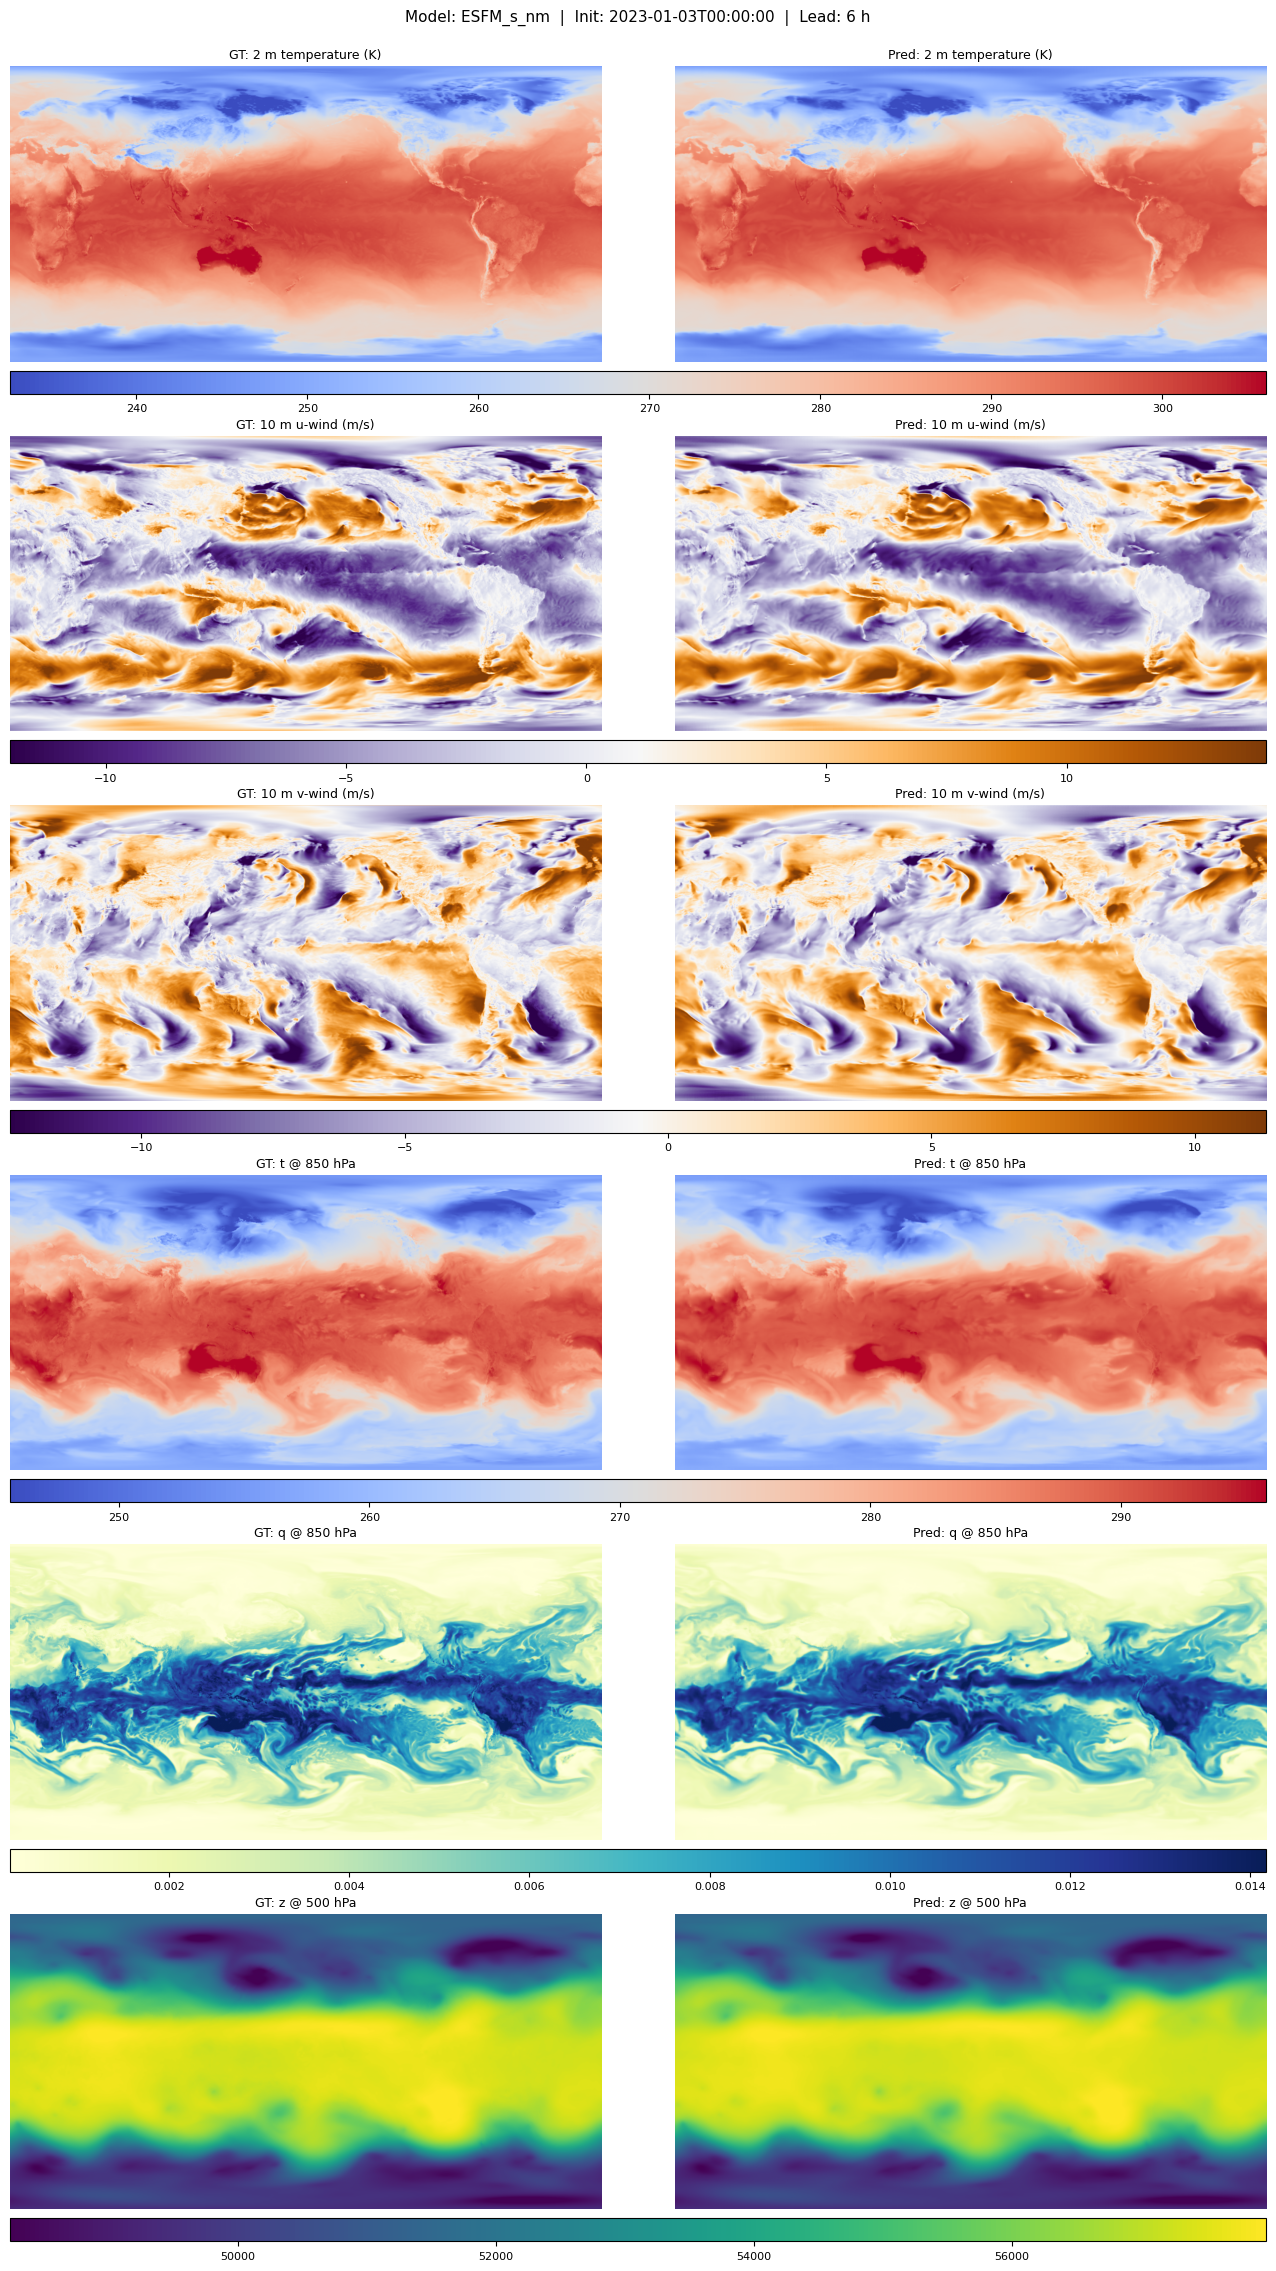

In [14]:

# ── Variables to visualise ────────────────────────────────────────────────────
PLOT_VARIABLES = [
    {'kind': 'surf',  'name': '2t',  'label': '2 m temperature (K)'},
    {'kind': 'surf',  'name': '10u', 'label': '10 m u-wind (m/s)'},
    {'kind': 'surf',  'name': '10v', 'label': '10 m v-wind (m/s)'},
    {'kind': 'atmos', 'name': 't',   'label': 'Temperature 850 hPa (K)',  'level_hpa': 850},
    {'kind': 'atmos', 'name': 'q',   'label': 'Specific humidity 850 hPa', 'level_hpa': 850},
    {'kind': 'atmos', 'name': 'z',   'label': 'Geopotential 500 hPa (m²/s²)', 'level_hpa': 500},
]

# Variable-specific colourmaps (diverging for wind components, sequential otherwise).
_CMAPS = {
    '2t': 'coolwarm', 't': 'coolwarm',
    '10u': 'PuOr_r',  '10v': 'PuOr_r', 'u': 'PuOr_r', 'v': 'PuOr_r',
    'z': 'viridis',   'q': 'YlGnBu',   'tp': 'Blues',
}
DEFAULT_CMAP  = 'cividis'


def _extract_field(batch_obj, sel: dict):
    """Extract a 2-D numpy array from a Batch for the given variable selection."""
    kind = sel['kind']
    name = sel['name']

    if kind == 'surf':
        if name not in batch_obj.surf_vars:
            raise KeyError(f"Surface variable '{name}' not in batch. "
                           f"Available: {sorted(batch_obj.surf_vars)}")
        arr = batch_obj.surf_vars[name].detach().cpu().numpy() # shape: (1, T, H, W)
        if arr.shape[0] != 1:
            return arr.squeeze()[-1]   # (H, W)
        return arr.squeeze()   # (H, W)

    if kind == 'atmos':
        if name not in batch_obj.atmos_vars:
            raise KeyError(f"Atmos variable '{name}' not in batch. "
                           f"Available: {sorted(batch_obj.atmos_vars)}")
        levels = np.asarray(
            batch_obj.metadata.atmos_levels_output
            or batch_obj.metadata.atmos_levels,
            dtype=float,
        )
        lvl_idx = int(np.argmin(np.abs(levels - float(sel['level_hpa']))))
        arr = batch_obj.atmos_vars[name].detach().cpu().numpy() # shape: (1, T, L, H, W)
        if arr.shape[0] != 1:
            return arr.squeeze()[-1, lvl_idx]  # (H, W)
        arr = arr.squeeze()    # collapse batch / time dims → (L, H, W)
        return arr[lvl_idx]    # (H, W)

    raise ValueError(f"Unknown kind '{kind}'. Use 'surf' or 'atmos'.")


def _percentile_union_clim(a: np.ndarray, b: np.ndarray, pct_low=0.5, pct_high=99.5):
    """Shared robust limits from finite GT+Pred values for one variable."""
    combined = np.concatenate([a.ravel(), b.ravel()])
    finite = combined[np.isfinite(combined)]
    if finite.size == 0:
        return -1.0, 1.0
    vmin, vmax = np.percentile(finite, [pct_low, pct_high])
    vmin, vmax = float(vmin), float(vmax)
    return (vmin, vmax) if vmin != vmax else (vmin - 1.0, vmax + 1.0)


# ── Plot ──────────────────────────────────────────────────────────────────────
n = len(PLOT_VARIABLES)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 3.8 * n), constrained_layout=False)
fig.subplots_adjust(left=0.03, right=0.97, top=0.97, bottom=0.03, wspace=0.02, hspace=0.250)
if n == 1:
    axes = axes[None]

for row, sel in enumerate(PLOT_VARIABLES):
    try:
        gt_field = _extract_field(batch_y, sel)
    except (KeyError, AttributeError):
        gt_field = np.full((batch_x.spatial_shape[0], batch_x.spatial_shape[1]), np.nan)

    try:
        pred_field = _extract_field(pred, sel)
    except (KeyError, AttributeError):
        print(f'Warning: Variable {sel} not found in predictions — filling image with NaNs.')
        pred_field = np.full((batch_x.spatial_shape[0], batch_x.spatial_shape[1]), np.nan)

    cmap_main = _CMAPS.get(sel['name'], DEFAULT_CMAP)
    vmin, vmax = _percentile_union_clim(gt_field, pred_field, pct_low=0.5, pct_high=99.5)

    label = sel.get('label', sel['name'])
    if sel['kind'] == 'atmos':
        label = f"{sel['name']} @ {sel['level_hpa']} hPa"

    ax_gt, ax_pr = axes[row]

    im0 = ax_gt.imshow(gt_field, cmap=cmap_main, vmin=vmin, vmax=vmax, aspect='equal')
    ax_gt.set_title(f'GT: {label}', fontsize=9)
    ax_gt.axis('off')

    im1 = ax_pr.imshow(pred_field, cmap=cmap_main, vmin=vmin, vmax=vmax, aspect='equal')
    ax_pr.set_title(f'Pred: {label}', fontsize=9)
    ax_pr.axis('off')

    # Build one horizontal colorbar axis that spans the full width of both subplots.
    pos_gt = ax_gt.get_position()
    pos_pr = ax_pr.get_position()
    cax_x0 = pos_gt.x0
    cax_x1 = pos_pr.x1
    cax_y0 = min(pos_gt.y0, pos_pr.y0) - 0.014
    cax_h = 0.010
    cax = fig.add_axes([cax_x0, cax_y0, cax_x1 - cax_x0, cax_h])
    cbar = fig.colorbar(im1, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f'Model: {EXPERIMENT_NAME}  |  Init: {INIT_TIME}  |  Lead: 6 h',
    fontsize=11, y=0.995,
)
plt.show()
